# Nitrogen-source plots: what this notebook does

**The big picture, in plain words**

We grew *E. coli* on 19 different nitrogen sources (ammonium, amino acids, nucleosides, ...).
For each one we ran a computer model of the cell (an **ME-model**, which simulates both
metabolism *and* the making of proteins) in two ways:

| Name in the code | What it means |
|---|---|
| **optimal** (`old_fluxes`, `uptake_constrained_...`) | The model is free to grow as fast as it can. This is the "ideal cell". |
| **constrained** (`new_fluxes`, `imod_constrained_...`) | The model is forced to make certain groups of genes (**iModulons**) at the levels we actually measured. This is closer to the "real cell". |

A **flux** is how fast a reaction runs (units: mmol per gram of dry cell per hour).
**μ (mu)** is the growth rate (per hour).

This notebook compares the two versions and asks: *what does the real cell spend its resources on
that the ideal cell would not, and what does that cost?*

**Words used throughout**
- **iModulon** – a group of genes that switch on and off together, controlled by one regulator
  (e.g. NtrC = nitrogen starvation, GadX = acid resistance, ArcA/Fnr = low oxygen).
- **Substrate groups A–D** – the nitrogen sources sorted into 4 groups that behave similarly.
- **Proteome** – all the protein in the cell. "% of proteome" = how much of the cell's protein is a given set of genes.
- **flux / μ** – flux divided by growth rate. Slow-growing cells have smaller fluxes overall, so dividing
  by μ lets us compare sources fairly ("how much per gram of new cell made").

**Order of the notebook**
1. Setup: load libraries and data
2. Define the groups (nitrogen sources and iModulons)
3. How much protein goes to the iModulons
4. Compare reaction fluxes between optimal and constrained
5. Figures: proteome bars, growth rates, energy (ATP) cost, the glutamine "futile cycle", respiration, and heatmaps

Figures are saved to the `figs/` folder.


## 1. Setup – load the tools

This cell just loads the Python libraries we need:
- `pandas` / `numpy` – tables and maths
- `cobra`, `cobrame`, `ecolime` – the metabolic / ME-model software
- `matplotlib` – plotting

The last two lines make saved PDFs keep text as real, editable text (handy for Illustrator).

In [1]:
# --- general data tools ---
import pandas as pd
import pickle
import pandas as pd
import numpy as np
import os


# --- ME-model / COBRA modelling tools ---
from cobrame.solve.algorithms import binary_search
from cobrame.solve.symbolic import compile_expressions
from cobra import Reaction, Metabolite
from cobra.io import load_json_model
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

import cobra 
import cobrame 
import Bio 
import pickle 
import ecolime
from os.path import dirname, abspath, join

# --- plotting ---
from matplotlib import pyplot as plt
from collections import OrderedDict
import matplotlib
# keep text editable in saved PDF / PS files
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


/home/jkrishnan/miniconda/envs/cobrame_env/lib/python3.6/site-packages/cobra/io/sbml3.py:24: UserWarning: Install lxml for faster SBML I/O
  warn("Install lxml for faster SBML I/O")
/home/jkrishnan/miniconda/envs/cobrame_env/lib/python3.6/site-packages/cobra/io/__init__.py:12: UserWarning: cobra.io.sbml requires libsbml
  warn("cobra.io.sbml requires libsbml")


## 2. Load the constrained fluxes

Read the table of reaction rates from the **constrained** model (the "real cell" version).
- Each **row** is a reaction.
- Each **column** is a nitrogen source.

In [2]:
# rows = reactions, columns = nitrogen sources, values = flux [mmol/gDW/h]
fluxes = pd.read_csv('fluxes/imod_constrained_fluxes.csv', index_col=0)
fluxes          # show the table


,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
biomass_dilution,0.741500,0.553000,0.124000,0.248500,0.487000,0.413500,0.135000,0.626000,0.418500,0.461000,0.238000,0.159000,0.279000,0.409500,0.403500,0.244500,0.177500,0.374500,0.205500
protein_biomass_to_biomass,0.293926,0.225950,0.053795,0.105340,0.200190,0.171290,0.058432,0.253844,0.173228,0.190013,0.101040,0.068474,0.117619,0.169728,0.167323,0.103685,0.076166,0.155789,0.087766
mRNA_biomass_to_biomass,0.002276,0.001458,0.000188,0.000458,0.001203,0.000941,0.000209,0.001765,0.000959,0.001106,0.000434,0.000257,0.000539,0.000927,0.000908,0.000449,0.000295,0.000814,0.000356
tRNA_biomass_to_biomass,0.013821,0.008855,0.001145,0.002788,0.007307,0.005719,0.001271,0.010722,0.005825,0.006719,0.002636,0.001561,0.003273,0.005635,0.005518,0.002732,0.001793,0.004949,0.002167
rRNA_biomass_to_biomass,0.098748,0.063261,0.008159,0.019917,0.052203,0.040853,0.009065,0.076591,0.041602,0.047993,0.018816,0.011136,0.023373,0.040242,0.039409,0.019497,0.012784,0.035333,0.015462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
protein_Fnr-3,1.184068,0.649933,0.350654,0.192115,0.646457,1.334218,0.270169,0.601057,0.392816,0.405280,0.333520,0.295811,0.720663,1.319149,0.347496,0.560771,3.019972,3.081680,1.745957
protein_GadX-2,0.304833,0.199296,0.257442,0.095323,0.345980,0.469480,0.359870,3.669429,4.987007,3.421991,1.794782,1.547414,3.792209,0.869652,3.237203,1.970201,0.734280,2.211058,0.469192
protein_ArcA-2,17.806898,9.996350,1.975450,4.070218,12.942924,12.094877,2.755267,14.688182,12.254045,11.424986,7.061758,4.788887,9.344990,11.835145,11.709824,7.110320,5.151667,12.230031,4.084041
protein_NtrC-1,0.555780,0.264636,0.550342,0.184904,0.791895,1.303104,0.742994,2.023402,0.241452,2.649017,0.151191,0.721109,0.457656,1.128704,0.203307,0.687020,0.938742,0.039637,1.493322


## 3. Define the groups

Here we write down, by hand, which nitrogen sources belong to which group (A–D),
and which iModulons we care about, sorted into 3 groups:

| iModulon group | Regulator | Roughly means |
|---|---|---|
| Group 1 | NtrC | nitrogen-starvation response |
| Group 2 | GadX | acid-resistance response |
| Group 3 | ArcA / Fnr | low-oxygen / respiration response |

At the end we list the model rows called `protein_<iModulon>`, which hold the total amount of protein made for each iModulon.

In [3]:
# the iModulons (co-regulated gene sets) we follow in this notebook
imods_to_consider = ['NtrC-1','NtrC-2','NtrC-3','GadX-1','GadX-2','ArcA-1','ArcA-2','Fnr-1','Fnr-2','Fnr-3']

# nitrogen sources, split into four groups (A-D) that behave alike
group_A_subs = [
    'NH4Cl',
    'Adenine',
    'L-Cys'
]

group_B_subs = [
    'Cytosine',
    'Cytidine'
]

group_C_subs = [
    'Putrescine',
    'L-Pro',
    'Adenosine',
    'L-Asn',
    'GlcNAc',
    'Glycine',
    'L-Orn',
    'L-Asp',
    'D-Ala',
    'L-Ala',
    'L-Arg'
]

group_D_subs = [
    'GABA',
    'L-Ser',
    'Guanosine'
]

# iModulons, split into three groups by their regulator
group_1_imods = ['NtrC-1','NtrC-2','NtrC-3']
group_2_imods = ['GadX-1','GadX-2']
group_3_imods = ['ArcA-1','ArcA-2','Fnr-1','Fnr-2','Fnr-3']

# ---------------------------------------------------------------- groupings
# substrate groups set the column order; iModulon groups set the panels

substrate_groups = OrderedDict([
    ('A', group_A_subs),
    ('B', group_B_subs),
    ('C', group_C_subs),
    ('D', group_D_subs),
])

imod_groups = OrderedDict([
    ('Group 1 (NtrC)',     group_1_imods),
    ('Group 2 (GadX)',     group_2_imods),
    ('Group 3 (ArcA/Fnr)', group_3_imods),
])


# model rows holding the total protein made for each iModulon (keep only those present)
sector_rows = ['protein_' + w for w in imods_to_consider]
sector_rows = [r for r in sector_rows if r in fluxes.index]

## 4. What fraction of the cell's protein goes to each iModulon group?

Steps:
1. Divide the protein made for each iModulon by the total protein made → a fraction of the proteome.
2. Put the nitrogen sources in a fixed order: by group (A→D), and fastest-growing first inside each group.
3. Add up the iModulons in each group (e.g. NtrC-1 + NtrC-2 + NtrC-3 → "Group 1").

The table printed at the end shows the % of proteome per group, per nitrogen source.

In [4]:
# Proteome mass fraction per sector
#
# protein_<sector> flux = sum_i ( MW_i [g/mol] * v_translation_i [mmol/gDW/h] )
#                       = mg protein / gDW / h
# protein_biomass_to_biomass  = g protein / gDW / h
# -> fraction of the proteome = protein_<sector> / 1000 / protein_biomass_to_biomass

sector_frac = fluxes.loc[sector_rows].div(
    fluxes.loc['protein_biomass_to_biomass'],
    axis=1
) / 1000.0

sector_frac.index = [i.replace('protein_', '') for i in sector_frac.index]

# ------------------------------------------------- column order: by substrate group,
# and within a group by growth rate (fastest first)
mu = fluxes.loc['biomass_dilution']        # growth rate of each nitrogen source [1/h]

source_order = []
substrate_blocks = OrderedDict()          # group -> its sources, in plot order

for gname, subs in substrate_groups.items():
    members = [s for s in subs if s in sector_frac.columns]
    # fastest-growing source first
    members = sorted(members, key=lambda s: -mu[s])
    substrate_blocks[gname] = members
    source_order += members

sector_frac = sector_frac[source_order]

# ------------------------------------------------- collapse iModulons into their groups
group_frac = pd.DataFrame(
    OrderedDict([
        (gname, sector_frac.loc[[m for m in members if m in sector_frac.index]].sum())
        for gname, members in imod_groups.items()
    ])
).T

# look-up table: nitrogen source -> its group letter (A-D)
source_group = pd.Series(
    {s: g for g, members in substrate_blocks.items() for s in members}
)

print("iModulon group allocation (% of proteome)")
(group_frac * 100).round(2)

iModulon group allocation (% of proteome)


,NH4Cl,Adenine,L-Cys,Cytidine,Cytosine,Adenosine,GlcNAc,L-Asn,Putrescine,D-Ala,L-Ala,L-Asp,L-Arg,Glycine,L-Orn,L-Pro,L-Ser,Guanosine,GABA
Group 1 (NtrC),2.36,1.21,2.12,8.44,4.04,7.68,6.65,4.50,6.28,3.48,4.38,4.87,6.49,4.71,5.32,7.01,2.30,8.43,5.16
Group 2 (GadX),0.31,0.27,1.84,0.56,0.27,5.80,7.16,10.93,0.83,2.04,8.37,12.47,8.29,8.21,8.63,2.32,5.92,2.53,4.09
Group 3 (ArcA/Fnr),15.83,12.31,10.13,16.23,9.70,15.01,16.63,18.63,18.54,18.21,17.75,20.55,17.74,17.28,17.66,11.78,23.41,15.34,25.04


## 5. Load the *optimal* fluxes

Same kind of table as before, but for the **optimal** model (free to grow as fast as possible).
We call it `old_fluxes`.

In [5]:
# growth-optimal solution: the model grows as fast as it can
old_fluxes = pd.read_csv('fluxes/uptake_constrained_fluxes.csv',index_col='Unnamed: 0')
old_fluxes

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
biomass_dilution,0.787500,0.706250,0.293750,0.450000,0.656250,0.606250,0.312500,0.756250,0.618750,0.637500,0.450000,0.350000,0.493750,0.606250,0.606250,0.462500,0.375000,0.575000,0.412500
protein_biomass_to_biomass,0.286165,0.203686,0.033505,0.077680,0.176146,0.145418,0.037069,0.235710,0.148808,0.167850,0.074730,0.044922,0.091391,0.143949,0.142036,0.076912,0.051602,0.130134,0.062260
mRNA_biomass_to_biomass,0.002306,0.001529,0.000158,0.000448,0.001263,0.000993,0.000179,0.001849,0.001029,0.001182,0.000431,0.000228,0.000554,0.000983,0.000970,0.000450,0.000271,0.000861,0.000343
tRNA_biomass_to_biomass,0.014001,0.009282,0.000957,0.002719,0.007665,0.006028,0.001087,0.011227,0.006246,0.007173,0.002616,0.001387,0.003364,0.005966,0.005888,0.002731,0.001647,0.005226,0.002082
rRNA_biomass_to_biomass,0.100023,0.066305,0.006828,0.019413,0.054752,0.043054,0.007757,0.080205,0.044616,0.051241,0.018680,0.009900,0.024025,0.042613,0.042052,0.019503,0.011756,0.037324,0.014867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b2963_lipid_modification_pg160_p_pg160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg160_p_pe160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg180_p_pg160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg180_p_pe160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Load the **constrained** fluxes again, this time as `new_fluxes`, so we can compare the two side by side.

In [6]:
# iModulon-constrained solution: gene groups forced to measured levels
new_fluxes = pd.read_csv('fluxes/imod_constrained_fluxes.csv',index_col='Unnamed: 0')
new_fluxes

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
biomass_dilution,0.741500,0.553000,0.124000,0.248500,0.487000,0.413500,0.135000,0.626000,0.418500,0.461000,0.238000,0.159000,0.279000,0.409500,0.403500,0.244500,0.177500,0.374500,0.205500
protein_biomass_to_biomass,0.293926,0.225950,0.053795,0.105340,0.200190,0.171290,0.058432,0.253844,0.173228,0.190013,0.101040,0.068474,0.117619,0.169728,0.167323,0.103685,0.076166,0.155789,0.087766
mRNA_biomass_to_biomass,0.002276,0.001458,0.000188,0.000458,0.001203,0.000941,0.000209,0.001765,0.000959,0.001106,0.000434,0.000257,0.000539,0.000927,0.000908,0.000449,0.000295,0.000814,0.000356
tRNA_biomass_to_biomass,0.013821,0.008855,0.001145,0.002788,0.007307,0.005719,0.001271,0.010722,0.005825,0.006719,0.002636,0.001561,0.003273,0.005635,0.005518,0.002732,0.001793,0.004949,0.002167
rRNA_biomass_to_biomass,0.098748,0.063261,0.008159,0.019917,0.052203,0.040853,0.009065,0.076591,0.041602,0.047993,0.018816,0.011136,0.023373,0.040242,0.039409,0.019497,0.012784,0.035333,0.015462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
protein_Fnr-3,1.184068,0.649933,0.350654,0.192115,0.646457,1.334218,0.270169,0.601057,0.392816,0.405280,0.333520,0.295811,0.720663,1.319149,0.347496,0.560771,3.019972,3.081680,1.745957
protein_GadX-2,0.304833,0.199296,0.257442,0.095323,0.345980,0.469480,0.359870,3.669429,4.987007,3.421991,1.794782,1.547414,3.792209,0.869652,3.237203,1.970201,0.734280,2.211058,0.469192
protein_ArcA-2,17.806898,9.996350,1.975450,4.070218,12.942924,12.094877,2.755267,14.688182,12.254045,11.424986,7.061758,4.788887,9.344990,11.835145,11.709824,7.110320,5.151667,12.230031,4.084041
protein_NtrC-1,0.555780,0.264636,0.550342,0.184904,0.791895,1.303104,0.742994,2.023402,0.241452,2.649017,0.151191,0.721109,0.457656,1.128704,0.203307,0.687020,0.938742,0.039637,1.493322


## 6. Clean up the fluxes so they can be compared

In the ME-model one real reaction can show up as many rows:
- a **forward** (`_FWD_`) and a **reverse** (`_REV_`) copy, and
- one copy for each enzyme that can do the job (isozymes).

This cell merges them into **one number per reaction**: forward counts as +, reverse counts as −.

Then we divide by growth rate (μ). The constrained cells grow slower, so *everything* gets smaller;
dividing by μ removes that effect so we only see real changes in how the cell routes its metabolism.

The printed table shows the growth rate of each source in both models and their ratio.

In [7]:
import re

# ---------------------------------------------------------------------------
# Collapse ME-model reaction IDs (<base>_FWD_<enzyme> / <base>_REV_<enzyme>)
# into ONE signed net flux per base reaction.
#
# Without this the comparison is swamped by
#   (i)  FWD/REV pairs both sitting at 1000 (unbounded thermodynamic loops),
#   (ii) isozyme splitting, which is arbitrary and differs between the two
#        solutions even when the net pathway flux is identical.
# ---------------------------------------------------------------------------

_DIR = re.compile(r'_(FWD|REV)_')

def net_flux(df):
    base, sign = [], []
    # for each reaction ID: strip the _FWD_/_REV_ part and remember the direction (+1 / -1)
    for rid in df.index:
        m = _DIR.search(rid)
        if m:
            base.append(rid[:m.start()])
            sign.append(1.0 if m.group(1) == 'FWD' else -1.0)
        else:                       # EX_, DM_, translation_, biomass_dilution, ...
            base.append(rid)
            sign.append(1.0)
    # flip REV rows to negative, then add up all rows that share the same base reaction
    return (df.mul(pd.Series(sign, index=df.index), axis=0)
              .groupby(pd.Index(base, name='reaction')).sum())

old_net = net_flux(old_fluxes)
new_net = net_flux(new_fluxes)

# keep only reactions and nitrogen sources present in both solutions
shared = old_net.index.intersection(new_net.index)
cols   = [c for c in old_net.columns if c in new_net.columns]
old_net, new_net = old_net.loc[shared, cols], new_net.loc[shared, cols]

# ---------------------------------------------------------------------------
# The constrained solutions grow much slower, so nearly every flux shrinks just
# from growing slower.  Dividing by mu gives flux per unit biomass produced and
# separates genuine rerouting from trivial rescaling.
# ---------------------------------------------------------------------------
mu_old = old_fluxes.loc['biomass_dilution', cols]
mu_new = new_fluxes.loc['biomass_dilution', cols]

old_spec = old_net.div(mu_old, axis=1)
new_spec = new_net.div(mu_new, axis=1)

print(f'{old_net.shape[0]} net reactions x {len(cols)} nitrogen sources')
# show growth rates side by side
pd.DataFrame({'mu_optimal': mu_old,
              'mu_constrained': mu_new,
              'mu_ratio': (mu_new / mu_old)}).round(3)

9671 net reactions x 19 nitrogen sources


,mu_optimal,mu_constrained,mu_ratio
NH4Cl,0.788,0.741,0.942
Adenine,0.706,0.553,0.783
L-Cys,0.294,0.124,0.422
Cytosine,0.450,0.248,0.552
Cytidine,0.656,0.487,0.742
Putrescine,0.606,0.414,0.682
L-Pro,0.312,0.135,0.432
Adenosine,0.756,0.626,0.828
L-Asn,0.619,0.418,0.676
GlcNAc,0.638,0.461,0.723


## 7. A helper to find the reactions that changed the most

`deviation_table(source)` gives, for one nitrogen source, the reactions that differ most between
the optimal and constrained models. You can rank by:
- `'raw'` – plain difference in flux
- `'specific'` – difference after dividing by μ (default, usually the best choice)
- `'fold'` – how many times bigger/smaller (good for spotting reactions that switch on or off)

Reactions that just build proteins/RNA ("machinery") are hidden, because they always follow growth rate.

In [8]:
# ME machinery pseudo-reactions (translation/transcription/complex formation/...)
# scale almost perfectly with mu and would otherwise fill every ranking.
MACHINERY = re.compile(r'^(translation|transcription|formation|charging'
                       r'|translocation|protein|RNA|DM_(protein|RNA))')


def deviation_table(source, metric='specific', top=15,
                    metabolic_only=True, min_flux=1e-3):
    """Reactions furthest from the unconstrained optimum for one nitrogen source.

    metric = 'raw'      -> |v_new - v_old|                     [mmol/gDW/h]
                           absolute rerouting; dominated by high-flux
                           energy / transport reactions.
    metric = 'specific' -> |v_new/mu_new - v_old/mu_old|       [mmol/gDW per g biomass]
                           growth-normalised, so it removes the trivial
                           "everything shrank because mu dropped" effect.
                           This is the default and usually what you want.
    metric = 'fold'     -> |log2(|v_new| / |v_old|)| on the growth-normalised
                           fluxes; surfaces low-flux reactions that switch
                           on/off or change by orders of magnitude.

    Returns the top `top` reactions with the optimal and constrained flux,
    their difference, the log2 fold change and whether the direction flipped.
    """
    # pick the plain or growth-normalised fluxes
    if metric == 'raw':
        o, n = old_net[source], new_net[source]
    else:
        o, n = old_spec[source], new_spec[source]

    # optionally hide protein/RNA-making 'machinery' reactions
    keep = o.index
    if metabolic_only:
        keep = keep[~keep.to_series().str.match(MACHINERY)]
    o, n = o[keep], n[keep]

    # ignore reactions that are numerically zero in both solutions
    active = (o.abs() >= min_flux) | (n.abs() >= min_flux)
    o, n = o[active], n[active]

    # fold change (small number added so we never divide by zero)
    log2fc = np.log2((n.abs() + min_flux) / (o.abs() + min_flux))
    score = log2fc.abs() if metric == 'fold' else (n - o).abs()

    # build the result table and sort, biggest change first
    out = pd.DataFrame({'optimal': o,
                        'constrained': n,
                        'difference': n - o,
                        'log2FC': log2fc,
                        'flipped': (np.sign(o) * np.sign(n)) < 0,
                        'score': score})
    return out.sort_values('score', ascending=False).head(top)


# # --- example: the two views for one source -------------------------------
# print('NH4Cl - largest growth-normalised deviations')
# display(deviation_table('NH4Cl', metric='specific', top=10).round(3))

# print('L-Arg - largest fold changes (on/off switches)')
# display(deviation_table('L-Arg', metric='fold', top=10).round(3))

*(Turned off – all lines start with `#`.)* Runs the helper above for **every** nitrogen source,
saves the result to a CSV, and counts which reactions change in many sources (a general effect)
versus only one or two (source-specific). Remove the `#`s to use it.

In [9]:
# # ---------------------------------------------------------------------------
# # Top deviating reactions for EVERY nitrogen source, in one long table
# # ---------------------------------------------------------------------------
# METRIC, TOP = 'specific', 15          # swap to 'fold' for on/off switches

# deviation = pd.concat(
#     {s: deviation_table(s, metric=METRIC, top=TOP) for s in cols},
#     names=['nitrogen_source', 'reaction']
# )
# deviation.to_csv(f'flux_deviation_top{TOP}_{METRIC}.csv')

# # reactions that are furthest-from-optimal in many sources = systematic,
# # ones appearing in only one or two = specific to that nitrogen source
# recurrence = (deviation.reset_index()
#                        .groupby('reaction')['nitrogen_source']
#                        .agg(n_sources='size', sources=lambda s: ', '.join(s))
#                        .sort_values('n_sources', ascending=False))

# print('recurrent (systematic) vs source-specific deviations')
# display(recurrence)

# for s in cols:
#     print(f'\n===== {s}   (mu {mu_old[s]:.3f} -> {mu_new[s]:.3f}) =====')
#     display(deviation.loc[s].round(3))

*(Turned off.)* One summary row per nitrogen source: how far, in total, the constrained model is
from the optimal one, which reaction changed the most, and how many reactions switched on, off, or reversed direction.

In [10]:
# # ---------------------------------------------------------------------------
# # How far is each nitrogen source overall from its unconstrained optimum?
# # ---------------------------------------------------------------------------
# _met = ~old_spec.index.to_series().str.match(MACHINERY).values
# O, N = old_spec[_met], new_spec[_met]

# delta = (N - O).abs()
# on   = (O.abs() < 1e-3) & (N.abs() >= 1e-3)
# off  = (O.abs() >= 1e-3) & (N.abs() < 1e-3)
# flip = (np.sign(O) * np.sign(N)) < 0

# distance = pd.DataFrame({
#     'mu_optimal':     mu_old,
#     'mu_constrained': mu_new,
#     'mu_ratio':       mu_new / mu_old,
#     'L1_deviation':   delta.sum(),            # total growth-normalised rerouting
#     'max_deviation':  delta.max(),
#     'worst_reaction': delta.idxmax(),
#     'n_switched_on':  on.sum(),
#     'n_switched_off': off.sum(),
#     'n_reversed':     flip.sum(),
# }).sort_values('L1_deviation', ascending=False)

# display(distance.round(3))

## 8. Figure: stacked bars of protein spent on iModulons

For each nitrogen source there are **two bars side by side**:
- left, faded = optimal model
- right, solid = constrained model

Each bar is stacked: red = NtrC, green = GadX, blue = ArcA/Fnr.
The height is the % of all protein in the cell that goes to those genes.

How it's calculated: for every gene, (protein weight × how fast it is made), added up over the
genes in the group, divided by total protein made. Each gene is counted only once, even if it
belongs to two groups.

Saved as `figs/proteome_allocation_stacked.png/.pdf`.

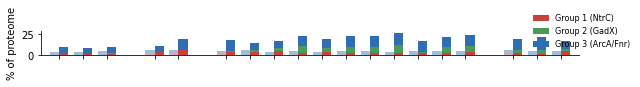

In [11]:

# ---------------------------------------------------------------------------
# Proteome allocation as stacked bars.
# Each substrate gets a pair of bars: left = growth-optimal, right =
# iModulon-constrained; each bar is stacked by iModulon group, so its height
# is the proteome fraction held by the sector iModulons.
#
# sector mass = sum_i MW_i * v_translation_i over the group's genes, divided
# by the total protein made (protein_biomass_to_biomass)
# ---------------------------------------------------------------------------
# how fast each protein is made (rows = genes) in both solutions
tr = {'optimal':     pd.read_csv('fluxes/uptake_constrained_translation_fluxes.csv', index_col=0),
      'constrained': pd.read_csv('fluxes/imod_constrained_translation_fluxes.csv', index_col=0)}
# total protein made in each solution
total = {'optimal': old_fluxes.loc['protein_biomass_to_biomass'],
         'constrained': new_fluxes.loc['protein_biomass_to_biomass']}

# load the ME-model only if it is not loaded yet (it is slow)
if 'base_me' not in globals():
    with open(join(dirname(abspath(ecolime.__file__)), "me_models", "iJL1678b.pickle"), "rb") as f:
        base_me = pickle.load(f)
# molecular weight of every protein [g/mol]
mw = pd.Series({g: base_me.metabolites.get_by_id('protein_' + g).formula_weight
                for g in tr['optimal'].index})

# each gene counted once: union within a group; a gene shared between groups
# goes to the first group it appears in (3 genes, NtrC before ArcA/Fnr)
group_genes, seen = OrderedDict(), set()
for gname, imods in imod_groups.items():
    genes = set().union(*[pd.read_pickle(f'imod_genes/{im}.pkl') for im in imods]) - seen
    group_genes[gname] = tr['optimal'].index.intersection(genes)
    seen |= genes

# % of proteome for each iModulon group, for one solution ('optimal' or 'constrained')
def group_percent(sol):
    return pd.DataFrame({g: tr[sol].loc[genes].mul(mw[genes], axis=0).sum() / 1000 / total[sol] * 100
                         for g, genes in group_genes.items()}).T   # rows = iModulon group

# ---- x layout: one unit per substrate, one blank unit between blocks ------
order, x, pos, block_centers = [], [], 0.0, OrderedDict()
for gname, subs in substrate_groups.items():
    subs = [s for s in subs if s in mu_new.index]
    start = pos
    for s in subs:
        order.append(s); x.append(pos); pos += 1
    block_centers[gname] = (start + pos - 1) / 2.0
    pos += 1
x = np.array(x)

# the numbers to plot, in plot order
alloc = {sol: group_percent(sol)[order] for sol in ('optimal', 'constrained')}

bw = 0.38                                           # width of each bar in a pair
x_opt, x_con = x - bw / 2, x + bw / 2
seg_colors = ['#C8423A', '#4A9A5B', '#2F6DB5']      # NtrC red, GadX green, ArcA/Fnr blue

fig, ax = plt.subplots(figsize=(9, 1))

# --- stacked proteome bars: faded = optimal, solid = constrained ----------
for xs, sol, alpha in [(x_opt, 'optimal', 0.45), (x_con, 'constrained', 1.0)]:
    bottom = np.zeros(len(order))
    for (gname, vals), color in zip(alloc[sol].iterrows(), seg_colors):
        ax.bar(xs, vals.values, bottom=bottom, width=bw, color=color, alpha=alpha,
               edgecolor='none', linewidth=0.6,
               label=gname if sol == 'constrained' else None)
        bottom += vals.values

# axis labels, legend and styling
ax.set_ylabel('% of proteome')
ax.set_xticks(x)
ax.set_xticklabels([], rotation=45, ha='right')
ax.set_xlim(-0.75, pos - 1.25)
ax.legend(loc='center', bbox_to_anchor=(1.005, 1.0), frameon=False, fontsize=8,
          title='', title_fontsize=7)
# for gname, xc in block_centers.items():
#     ax.text(xc, 1.03, f'Group {gname}', ha='center', va='bottom', fontsize=10,
#             transform=ax.get_xaxis_transform())
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.tight_layout()
# save as PNG and PDF
fig.savefig('figs/proteome_allocation_stacked.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/proteome_allocation_stacked.pdf', bbox_inches='tight', transparent=True)
plt.show()

## 9. Figure: the same proteome numbers, one panel per iModulon group

Three stacked panels (NtrC, GadX, ArcA/Fnr), constrained model only.
Each bar is shaded from light (lowest value in that panel) to dark (highest), so it's easy to see
which nitrogen sources use the most.

Saved as `figs/proteome_allocation_panels.png/.pdf`.

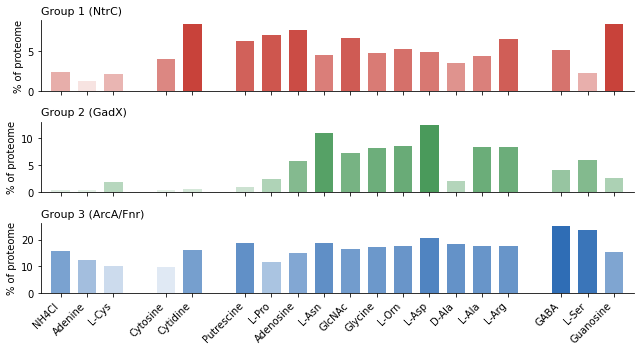

In [12]:
# ---------------------------------------------------------------------------
# Proteome allocation bar chart: one panel per iModulon group
# each panel is shaded light -> full by value, with its own colourbar
# ---------------------------------------------------------------------------
sub_groups = OrderedDict([
    ('A', group_A_subs),
    ('B', group_B_subs),
    ('C', group_C_subs),
    ('D', group_D_subs),
])

# ---- x layout: one unit per substrate, one blank unit between blocks ------
order, x, pos = [], [], 0.0
block_centers, block_slices = OrderedDict(), OrderedDict()

for gname, subs in sub_groups.items():
    subs = [s for s in subs if s in group_frac.columns]
    start, i0 = pos, len(order)
    for s in subs:
        order.append(s)
        x.append(pos)
        pos += 1
    block_centers[gname] = (start + pos - 1) / 2.0
    block_slices[gname] = slice(i0, len(order))
    pos += 1

df = group_frac[order] * 100      # fractions -> %
x = np.array(x)

n_panels = df.shape[0]
# one panel (row) per iModulon group, all sharing the same x axis
fig, bar_axes = plt.subplots(n_panels, 1, figsize=(9, 5), sharex=True)

# --- the proteome bars: each panel shaded light -> full in its own colour --
panel_colors =['#C8423A', '#4A9A5B', '#2F6DB5']#['#5E4B8B', '#5E4B8B', '#5E4B8B']#['#8C8C8C', '#8C8C8C', '#8C8C8C']      # NtrC grey, GadX blue, ArcA/Fnr yellow

for ax, (name, row), color in zip(bar_axes, df.iterrows(), panel_colors):
    vals = row.values
    # colour scale from a pale tint (lowest value) to the full colour (highest)
    light = 0.85 + 0.15 * np.array(mpl.colors.to_rgb(color))   # 15% tint for the lowest value
    cmap = LinearSegmentedColormap.from_list(name, [light, color])
    row_norm = mpl.colors.PowerNorm(gamma=0.6, vmin=vals.min(), vmax=vals.max())
    bar_colors = cmap(row_norm(vals))

    # draw the bars
    ax.bar(x, vals, color=bar_colors, width=0.7,
           edgecolor="none", linewidth=1)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_ylabel("% of proteome")
    # cb = fig.colorbar(mpl.cm.ScalarMappable(norm=row_norm, cmap=cmap),
    #                   cax=ax.inset_axes([1.02, 0.1, 0.012, 0.8]))   # outside the axes, keeps x aligned
    # cb.ax.tick_params(labelsize=7)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

bar_axes[0].set_xlim(-0.75, pos - 1.25)

# group labels above the top panel (x in data coords, y in axes coords)

# only the bottom panel gets the nitrogen-source names
bar_axes[-1].set_xticks(x)
bar_axes[-1].set_xticklabels(df.columns, rotation=45, ha="right")

fig.tight_layout()
# save as PNG and PDF
fig.savefig('figs/proteome_allocation_panels.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/proteome_allocation_panels.pdf', bbox_inches='tight', transparent=True)
plt.show()

## 10. Figure: growth rate, optimal vs measured

For each nitrogen source:
- **hollow bar** = how fast the optimal model grows
- **grey bar** = how fast the constrained model grows (matches the experiment)

The gap shows how much growth the real cell "gives up".
It reuses the x positions from the figure above, so the bars line up with it.

Saved as `figs/growth_rate_optimal_vs_constrained.png/.pdf`.

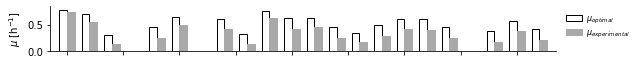

In [13]:
# ---------------------------------------------------------------------------
# Growth rates: each substrate gets a paired bar: hollow = each source's
# optimal mu, filled = experimental (constrained) mu, joined by a line from
# the top of the optimal bar to the top of the experimental bar.
# uses the x layout (order, x, pos, block_centers) from the cell above
# ---------------------------------------------------------------------------
mu_c = mu_new[order].values          # experimental (constrained) mu [1/h]
mu_o = mu_old[order].values          # each source's own optimum     [1/h]

fig, ax_mu = plt.subplots(figsize=(9, 1))

bw = 0.35                            # width of each bar in a pair (pair = 0.7)
x_opt = x - bw / 2                   # optimal on the left
x_exp = x + bw / 2                   # experimental on the right

# hollow bars: optimal growth rate
ax_mu.bar(x_opt, mu_o, width=bw, facecolor='none', edgecolor='black',
          linewidth=1.0, zorder=2, label=r'$\mu_{optimal}$')
# grey bars: measured (constrained) growth rate
ax_mu.bar(x_exp, mu_c, width=bw, facecolor='darkgrey', edgecolor='darkgrey',
          linewidth=1.0, zorder=2, label=r'$\mu_{experimental}$')



# axis limits, labels, legend
ax_mu.set_xlim(-0.75, pos - 1.25)
ax_mu.set_ylim(0, max(mu_o.max(), mu_c.max()) * 1.08)
ax_mu.set_ylabel(r'$\mu$ [h$^{-1}$]')
#ax_mu.set_xticks()
ax_mu.set_xticklabels([], rotation=45, ha="right")
for s in ("top", "right"):
    ax_mu.spines[s].set_visible(False)
ax_mu.legend(loc='upper left', bbox_to_anchor=(1.005, 1.0), frameon=False,
             fontsize=8, handletextpad=0.5, labelspacing=0.3)

fig.tight_layout()
# save as PNG and PDF
fig.savefig('figs/growth_rate_optimal_vs_constrained.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/growth_rate_optimal_vs_constrained.pdf', bbox_inches='tight', transparent=True)
plt.show()

Give the optimal fluxes a second, more descriptive name (`growth_constrained_fluxes`) for the energy cells below.

In [14]:
# same as the optimal solution, just a clearer name for the ATP cells below
growth_constrained_fluxes = old_fluxes#pd.read_csv('growth_constrained_fluxes.csv', index_col=0)
growth_constrained_fluxes

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
biomass_dilution,0.787500,0.706250,0.293750,0.450000,0.656250,0.606250,0.312500,0.756250,0.618750,0.637500,0.450000,0.350000,0.493750,0.606250,0.606250,0.462500,0.375000,0.575000,0.412500
protein_biomass_to_biomass,0.286165,0.203686,0.033505,0.077680,0.176146,0.145418,0.037069,0.235710,0.148808,0.167850,0.074730,0.044922,0.091391,0.143949,0.142036,0.076912,0.051602,0.130134,0.062260
mRNA_biomass_to_biomass,0.002306,0.001529,0.000158,0.000448,0.001263,0.000993,0.000179,0.001849,0.001029,0.001182,0.000431,0.000228,0.000554,0.000983,0.000970,0.000450,0.000271,0.000861,0.000343
tRNA_biomass_to_biomass,0.014001,0.009282,0.000957,0.002719,0.007665,0.006028,0.001087,0.011227,0.006246,0.007173,0.002616,0.001387,0.003364,0.005966,0.005888,0.002731,0.001647,0.005226,0.002082
rRNA_biomass_to_biomass,0.100023,0.066305,0.006828,0.019413,0.054752,0.043054,0.007757,0.080205,0.044616,0.051241,0.018680,0.009900,0.024025,0.042613,0.042052,0.019503,0.011756,0.037324,0.014867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b2963_lipid_modification_pg160_p_pg160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg160_p_pe160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg180_p_pg160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
b2963_lipid_modification_pg180_p_pe160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 11. Load the full ME-model

Load the saved model file (`iJL1678b.pickle`). We need it to look up details about each reaction,
such as how much ATP it uses and which genes make its enzyme.

In [15]:
# find where the ecolime package is installed and load the saved ME-model
ecoli_dir = dirname(abspath(ecolime.__file__)) 
model_file = join(ecoli_dir, "me_models", "iJL1678b.pickle") 


with open(model_file, "rb") as f:
    base_me = pickle.load(f)

## 12. Extra energy (ATP + GTP) used by the constrained cell

`atp_use` adds up the ATP and GTP every reaction uses, and groups them by reaction type
(metabolism, making proteins, etc.).

We subtract the optimal model from the constrained model → **extra energy** the real cell spends.
- The bar chart shows the extra energy per nitrogen source, split by reaction type.
- The printed numbers are the extra energy as a % of the optimal model's energy use.

⚠️ Note: `from cobrame import mu` here replaces the earlier `mu` (the growth-rate list) with a model symbol.

NH4Cl          17.2
Adenine        26.5
L-Cys          49.4
Cytosine       16.5
Cytidine       36.8
Putrescine     31.1
L-Pro          73.5
Adenosine      48.4
L-Asn          82.8
GlcNAc         61.6
Glycine        97.5
L-Orn         147.3
L-Asp         121.5
D-Ala          36.3
L-Ala          60.4
L-Arg          95.6
GABA           71.6
L-Ser          59.7
Guanosine      53.1
dtype: float64

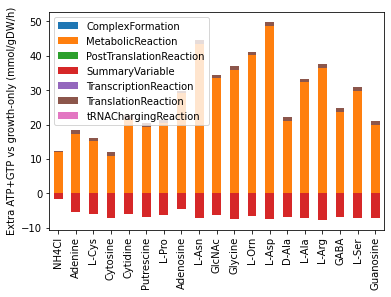

In [16]:
from cobrame import mu   # the growth-rate symbol used inside model formulas (replaces the earlier mu table!)
# ATP + GTP used by every reaction, summed by reaction type (metabolic, translation, ...)
def atp_use(F):
    # reactions that are in the flux table and touch ATP or GTP
    rx = [r for r in base_me.reactions if r.id in F.index and any(m.id in ('atp_c','gtp_c') for m in r.metabolites)]
    # ATP+GTP consumed per unit flux (some coefficients depend on growth rate, so plug in mu)
    c = lambda r, g: -sum(float(v.subs(mu, g)) if hasattr(v, 'subs') else v for m, v in r.metabolites.items() if m.id in ('atp_c','gtp_c'))
    # energy used = coefficient x flux, for every reaction and nitrogen source
    u = pd.DataFrame({s: {r.id: c(r, F.loc['biomass_dilution', s]) * F.loc[r.id, s] for r in rx} for s in F})
    # keep only consumption (drop production) and sum by reaction type
    return u.clip(lower=0).groupby(lambda i: type(base_me.reactions.get_by_id(i)).__name__).sum()

imod = fluxes            # your iModulon-constrained table
# extra energy the constrained cell spends compared with the optimal cell
extra = atp_use(imod) - atp_use(growth_constrained_fluxes)
extra.T.plot.bar(stacked=True, ylabel='Extra ATP+GTP vs growth-only (mmol/gDW/h)')
(extra.sum() / atp_use(growth_constrained_fluxes).sum() * 100).round(1)   # % extra energy per substrate


## 13. Which metabolic reactions use that extra energy?

Same idea, but per reaction (metabolism only). Forward/reverse copies and isozymes are merged.
Shows the 15 reactions whose ATP use changed the most.

In [17]:
def atp_rxn(F):   # per-reaction ATP+GTP consumed, no grouping
    # metabolic reactions that use ATP or GTP
    rx = [r for r in base_me.reactions if r.id in F.index and isinstance(r, cobrame.MetabolicReaction)
          and any(m.id in ('atp_c','gtp_c') for m in r.metabolites)]
    # ATP+GTP consumed per unit flux
    c = lambda r: -sum(float(v) for m, v in r.metabolites.items() if m.id in ('atp_c','gtp_c'))
    return pd.DataFrame({s: {r.id: c(r) * F.loc[r.id, s] for r in rx} for s in F})

# extra ATP+GTP per reaction (constrained minus optimal)
d = atp_rxn(imod) - atp_rxn(growth_constrained_fluxes)
d = d.groupby(lambda i: re.sub(r'_(FWD|REV)_.*', '', i)).sum()   # net per base reaction, isozymes merged
# show the 15 reactions with the biggest change
d.loc[d.abs().max(axis=1).sort_values(ascending=False).index[:15]].round(1)

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
GLNS,0.9,0.7,4.6,0.8,1.4,2.4,5.9,13.0,26.6,16.5,16.8,21.7,30.3,4.6,17.8,17.9,9.2,13.1,5.1
ATPS4rpp,6.9,13.5,12.2,18.8,27.5,28.8,12.6,-1.2,-2.5,-2.6,17.9,14.4,1.8,24.6,8.1,16.3,16.0,17.2,15.9
PYK,-5.8,-11.9,-8.3,-10.1,-18.0,-15.7,-10.6,-12.2,-13.2,-7.4,-16.3,-16.9,-15.3,-15.3,-12.0,-16.1,-12.3,-14.7,-12.5
SUCOAS,-2.4,-4.3,-5.7,-7.4,-11.0,-14.3,-7.1,-1.5,-11.4,-7.2,-16.1,-15.3,-17.3,-12.3,-12.4,-14.8,-10.8,-14.3,-6.2
PGK,-3.9,-4.3,-4.9,-4.5,-11.6,-9.4,-6.6,-5.6,-5.7,-4.9,-11.4,-13.2,-9.6,-10.2,-6.6,-11.0,-7.2,-9.4,-7.7
HEX1,2.2,7.6,5.3,6.7,9.8,9.7,5.9,6.6,8.9,3.2,9.9,9.9,9.9,8.9,8.4,9.9,6.9,9.3,7.2
PFK,3.4,4.0,2.6,3.1,7.8,4.6,3.2,5.3,2.8,3.9,6.2,6.4,4.8,6.1,3.2,5.8,3.5,5.2,4.8
ACKr,0.4,0.4,0.7,0.2,0.3,0.2,0.1,0.4,1.2,5.2,1.0,0.1,3.5,1.2,1.2,0.4,0.8,1.2,0.9
FE3abcpp,0.0,0.0,0.0,0.0,0.0,0.0,2.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PPCK,0.0,0.0,0.0,0.0,0.0,0.9,1.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.0,0.0


## 14. Figure: extra ATP spent by glutamine synthetase (GLNS) vs growth

**Background – the glutamine "futile cycle":**
- **GLUN** (glutaminase) breaks glutamine → glutamate + ammonia
- **GLNS** (glutamine synthetase) rebuilds glutamine from glutamate + ammonia, **using ATP**

Running both at the same time goes in a circle and just burns ATP.

This plot shows, for each nitrogen source:
- **x axis**: measured growth ÷ optimal growth (1 = as fast as the ideal cell)
- **y axis**: extra ATP spent by GLNS per gram of new cell
- dots coloured by substrate group; dashed line = best-fit line with its correlation (r) and p-value.

Saved as `figs/glns_atp_per_mu_vs_relative_growth.*`.

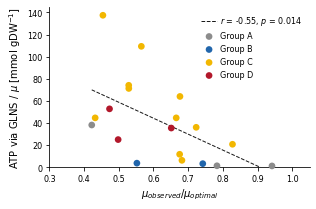

,mu_rel,GLNS_ATP_per_mu,group
NH4Cl,0.942,1.324,A
Adenosine,0.828,20.892,C
Adenine,0.783,1.469,A
Cytidine,0.742,3.378,B
GlcNAc,0.723,36.202,C
Putrescine,0.682,6.382,C
L-Asn,0.676,64.074,C
D-Ala,0.675,11.853,C
L-Ala,0.666,44.738,C
L-Ser,0.651,35.543,D


In [19]:

# ---------------------------------------------------------------------------
# Extra ATP consumed by glutamine synthetase (GLNS) per unit biomass
# vs relative growth rate
#
# ATP via GLNS is computed per solution with atp_rxn (previous cells),
# FWD/REV and isozymes merged into one row per base reaction, then each
# solution is divided by its OWN growth rate before subtracting:
#
#     dATP/mu = ATP_GLNS,constrained / mu_observed
#             - ATP_GLNS,optimal     / mu_optimal         [mmol/gDW]
#
# i.e. the extra ATP spent on the GLNS/GLUN futile glutamine cycle per gram
# of biomass made, comparable across substrates that grow at different rates
# (same normalisation as new_spec - old_spec in the flux-deviation heatmap)
#
# x-axis: mu_observed / mu_optimal, i.e. how close each source gets to the
#         growth rate of its own growth-only optimum
# dotted line: least-squares fit across all sources, Pearson r in the legend
# ---------------------------------------------------------------------------
from scipy.stats import linregress

base_rxn = lambda i: re.sub(r'_(FWD|REV)_.*', '', i)
atp_c = atp_rxn(imod).groupby(base_rxn).sum()                        # constrained [mmol/gDW/h]
atp_o = atp_rxn(growth_constrained_fluxes).groupby(base_rxn).sum()   # optimum     [mmol/gDW/h]

mu_obs   = imod.loc['biomass_dilution']                         # iModulon-constrained mu
mu_opt   = growth_constrained_fluxes.loc['biomass_dilution']    # growth-only optimum
mu_rel   = mu_obs / mu_opt                                      # relative growth rate

# extra ATP used by GLNS per gram of new cell (constrained minus optimal)
glns_atp_spec = atp_c.loc['GLNS'] / mu_obs - atp_o.loc['GLNS'] / mu_opt   # [mmol/gDW]

# one row per source: relative growth, extra GLNS ATP and its group
ngam = (pd.DataFrame({'mu_rel': mu_rel, 'GLNS_ATP_per_mu': glns_atp_spec})
          .dropna()
          .assign(group=lambda t: t.index.map(source_group))
          .sort_values('mu_rel', ascending=False))

group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# make the scatter plot, one colour per substrate group
fig, ax = plt.subplots(figsize=(4.5, 3))

# black-edged markers, same as the needle / coupling plots
for g, sub in ngam.groupby('group'):
    ax.scatter(sub['mu_rel'], sub['GLNS_ATP_per_mu'], s=45,
               facecolor=group_colors.get(g, '0.6'), edgecolor='none',
               linewidth=0.6, zorder=6, label=f'Group {g}',clip_on=False)

# for s, row in ngam.iterrows():
#     ax.annotate(s, (row['mu_rel'], row['GLNS_ATP_per_mu']),
#                 textcoords='offset points', xytext=(4, 4),
#                 fontsize=7, color='0.25', clip_on=False)

# --- correlation line -----------------------------------------------------
fit = linregress(ngam['mu_rel'], ngam['GLNS_ATP_per_mu'])
xfit = np.linspace(ngam['mu_rel'].min(), ngam['mu_rel'].max(), 100)
ax.plot(xfit, fit.intercept + fit.slope * xfit,
        color='0.1', lw=1.0, ls='--', zorder=5,
        label=rf'$r$ = {fit.rvalue:.2f}, $p$ = {fit.pvalue:.2g}')

#ax.set_title('ATP spent on GLNS', loc='left', fontsize=11)
# axis labels and styling
ax.set_xlabel(r'$\mu_{observed}/\mu_{optimal}$', fontsize=10)
ax.set_ylabel(r'ATP via GLNS / $\mu$ [mmol gDW$^{-1}$]', fontsize=10)
ax.set_xlim(0.3, max(1.0, ngam['mu_rel'].max()) * 1.05)
ax.set_ylim(bottom=min(0, ngam['GLNS_ATP_per_mu'].min() * 1.1))
ax.tick_params(labelsize=8)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc='upper right', handletextpad=0.4)

fig.tight_layout()
# save as PNG, PDF and SVG
fig.savefig('figs/glns_atp_per_mu_vs_relative_growth.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/glns_atp_per_mu_vs_relative_growth.pdf', bbox_inches='tight', transparent=True)
fig.savefig('figs/glns_atp_per_mu_vs_relative_growth.svg', bbox_inches='tight', transparent=True)
plt.show()

ngam.round(3)          # show the numbers behind the plot

## 15. Figure: is the futile cycle driven by gene *glsA* (ybaS)?

Gene **b0485** (called *ybaS* or *glsA*) makes the glutaminase enzyme. It belongs to the GadX iModulon.

Steps:
1. Load the measured gene expression (TPM = how much RNA of each gene) and average the repeats for each nitrogen source.
2. Get the GLUN flux in the constrained model and divide by growth rate.
3. Plot expression (x) vs GLUN flux per μ (y), with a best-fit line.

If they line up, it means: the more the cell expresses this gene, the more the model has to run the wasteful cycle.

Saved as `figs/ybas_vs_glun_per_mu.*`.

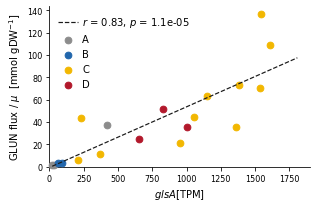

In [41]:
# ---------------------------------------------------------------------------
# ybaS expression vs growth-normalised glutaminase (GLUN) flux
#
#   b0485 = ybaS, acid-resistance glutaminase, in GadX-1 / GadX-2  -> GLUN
#
# GadX forces ybaS expression; the model runs glutaminase in proportion,
# and GLNS follows 1:1 to regenerate the glutamine (futile cycle).
# dotted line: least-squares fit across all sources, Pearson r in the legend
# ---------------------------------------------------------------------------
from scipy.stats import linregress

# average replicate TPMs into one column per nitrogen source
tpm_metadata = pd.read_excel('sample_table_TPMcolumn_to_nitrogen_source.xlsx',
                             engine='openpyxl')
tpm = pd.read_csv('tpm_qc_nitrogen42_labeled.csv').set_index('gene')

col_to_source = dict(zip(tpm_metadata['tpm_column'],
                         tpm_metadata['nitrogen_source']))
sample_to_source = {c: col_to_source[c.split('__', 1)[-1]] for c in tpm.columns}

# rename each sample column to its nitrogen source, then average the repeats
tpm_by_source = tpm.rename(columns=sample_to_source).T.groupby(level=0).mean().T

# constrained fluxes and the growth-rate table
imod   = pd.read_csv('fluxes/imod_constrained_fluxes.csv', index_col=0)
growth = pd.read_csv('fluxes/uptake_constrained_growth.csv', index_col=0)
srcs   = list(imod.columns)

glun = imod.loc[imod.index.str.startswith('GLUN_')].sum()[srcs]   # [mmol/gDW/h]
mu   = growth['mu_obs'][srcs]                                      # [1/h]

# table: glsA expression vs GLUN flux per mu, plus the group of each source
ybas = (pd.DataFrame({'ybaS_TPM': tpm_by_source.loc['b0485', srcs],
                      'GLUN_per_mu': glun / mu})                   # [mmol/gDW]
          .dropna()
          .assign(group=lambda t: t.index.map(source_group)))

group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# scatter plot, one colour per substrate group
fig, ax = plt.subplots(figsize=(4.5, 3))

for g, sub in ybas.groupby('group'):
    ax.scatter(sub['ybaS_TPM'], sub['GLUN_per_mu'], s=45,
               facecolor=group_colors.get(g, '0.6'),
               edgecolor=group_colors.get(g, '0.6'), linewidth=1, zorder=6,
               label=f'{g}', clip_on=False)

# for s, row in ybas.iterrows():
#     ax.annotate(s, (row['ybaS_TPM'], row['GLUN_per_mu']),
#                 textcoords='offset points', xytext=(4, 4),
#                 fontsize=7, color='0.25', clip_on=False)

# --- correlation line -----------------------------------------------------
fit = linregress(ybas['ybaS_TPM'], ybas['GLUN_per_mu'])
xfit = np.linspace(ybas['ybaS_TPM'].min(), ybas['ybaS_TPM'].max()+200, 100)
ax.plot(xfit, fit.intercept + fit.slope * xfit,
        color='0.1', lw=1.2, ls='--', zorder=6,
        label=rf'$r$ = {fit.rvalue:.2f}, $p$ = {fit.pvalue:.2g}')

# axis labels and styling
ax.set_xlabel(r'$glsA $[TPM]',fontsize=10)
ax.set_ylabel(r'GLUN flux / $\mu$  [mmol gDW$^{-1}$]',fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=8)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='best', handletextpad=0.4)

fig.tight_layout()
# save as PNG and PDF
fig.savefig('figs/ybas_vs_glun_per_mu.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/ybas_vs_glun_per_mu.pdf', bbox_inches='tight', transparent=True)
plt.show()

## 16. Figure: GLNS and GLUN move together

Plot the glutamine-breaking flux (GLUN, x) against the glutamine-building flux (GLNS, y).
If they are a tight cycle, the points fall on a straight line.

⚠️ This cell uses `lim`, which is defined only in the commented-out block. Remove the `#`
in front of the `lim = ...` line, or this cell will give an error.

Saved as `figs/glns_vs_glun_coupling.*`.

NameError: name 'lim' is not defined

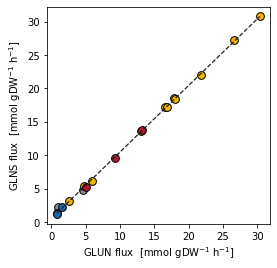

In [29]:
# ---------------------------------------------------------------------------
# Coupling of the futile GLNS/GLUN glutamine cycle
#
#   GLUN : glutamine -> glutamate + NH4          (ybaS, forced by GadX)
#   GLNS : glutamate + NH4 + ATP -> glutamine    (glnA)
#
# Every glutamine the constraints force through GLUN has to be regenerated
# by GLNS, so the two fluxes should sit on the 1:1 line; the gap below/above
# it is glutamine going to (or coming from) the rest of the network.
# dashed line: 1:1;  dotted line: least-squares fit, slope and r in legend
# ---------------------------------------------------------------------------
from scipy.stats import linregress

imod = pd.read_csv('fluxes/imod_constrained_fluxes.csv', index_col=0)
srcs = list(imod.columns)

# total flux through all GLNS / GLUN copies (all enzymes, all directions)
glns_f = imod.loc[imod.index.str.startswith('GLNS_')].sum()[srcs]   # [mmol/gDW/h]
glun_f = imod.loc[imod.index.str.startswith('GLUN_')].sum()[srcs]   # [mmol/gDW/h]

# table of the two fluxes per nitrogen source, plus its group
cyc = (pd.DataFrame({'GLUN': glun_f, 'GLNS': glns_f})
         .dropna()
         .assign(group=lambda t: t.index.map(source_group)))

group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# scatter plot, one colour per substrate group
fig, ax = plt.subplots(figsize=(4, 4))

for g, sub in cyc.groupby('group'):
    ax.scatter(sub['GLUN'], sub['GLNS'], s=60,
               facecolor=group_colors.get(g, '0.6'),
               edgecolor='black', linewidth=1, zorder=6,
               label=f'Group {g}')

# for s, row in cyc.iterrows():
#     ax.annotate(s, (row['GLUN'], row['GLNS']),
#                 textcoords='offset points', xytext=(4, 4),
#                 fontsize=7, color='0.25', clip_on=False)

# # --- 1:1 reference and correlation line -----------------------------------
# lim = [0, max(cyc['GLUN'].max(), cyc['GLNS'].max()) * 1.05]
# ax.plot(lim, lim, color='0.6', lw=0.8, ls='--', zorder=1, label='1:1')

# best-fit straight line through all points
fit = linregress(cyc['GLUN'], cyc['GLNS'])
xfit = np.linspace(cyc['GLUN'].min(), cyc['GLUN'].max(), 100)
ax.plot(xfit, fit.intercept + fit.slope * xfit,
        color='0.1', lw=1.2, ls='--', zorder=6,
        label=rf'r = {fit.rvalue:.2f}')

# axis labels, limits (needs `lim` from above!) and styling
ax.set_xlabel(r'GLUN flux  [mmol gDW$^{-1}$ h$^{-1}$]')
ax.set_ylabel(r'GLNS flux  [mmol gDW$^{-1}$ h$^{-1}$]')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(labelsize=8)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc='upper left', handletextpad=0.4)

fig.tight_layout()
# save as PNG, PDF and SVG
fig.savefig('figs/glns_vs_glun_coupling.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/glns_vs_glun_coupling.pdf', bbox_inches='tight', transparent=True)
fig.savefig('figs/glns_vs_glun_coupling.svg', bbox_inches='tight', transparent=True)
plt.show()



## 17. Figure: GLNS flux per μ, by substrate group

A box plot for each substrate group A–D, with two boxes per group:
- **left, solid, coloured dots** = constrained model
- **right, dashed, white dots** = optimal model

Box = middle 50% of values, line = median, whiskers = min and max, dots = the individual nitrogen sources.

Saved as `figs/glns_per_mu_by_group.*`.

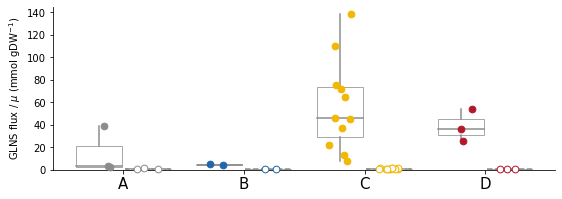

In [42]:

# GLNS flux / mu per substrate group: box = interquartile range, line = median,
# whiskers = min / max
# solid = iModulon-constrained, dashed = growth-optimal
# load both solutions
imod = pd.read_csv('fluxes/imod_constrained_fluxes.csv', index_col=0)
opt  = pd.read_csv('fluxes/uptake_constrained_fluxes.csv', index_col=0)

# total GLNS flux divided by growth rate, for every nitrogen source
def glns_per_mu(F):
    return F.loc[F.index.str.startswith('GLNS_')].sum() / F.loc['biomass_dilution']

# one row per source: both solutions plus its group letter
df = pd.DataFrame({'constrained': glns_per_mu(imod), 'optimal': glns_per_mu(opt)})
df['group'] = df.index.map(source_group)
df = df.dropna()

groups = ['A', 'B', 'C', 'D']
colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

W = 1.6                                   # box width -- change this
fig, ax = plt.subplots(figsize=(9, 3))
for i, g in enumerate(groups):
    sub = df[df['group'] == g]               # the nitrogen sources in this group
    # left box = constrained (solid), right box = optimal (dashed)
    for dx, col, ls, face in [(-W/2 - 0.05, 'constrained', '-', colors[g]), (W/2 + 0.05, 'optimal', '--', 'white')]:
        x = (2 * W + 1) * i + dx
        # box from the 25th to 75th percentile, line at the median
        q1, med, q3 = sub[col].quantile([0.25, 0.5, 0.75])
        ax.bar(x, q3 - q1, bottom=q1, width=W, fill=False, edgecolor='darkgrey', linestyle=ls)
        ax.plot([x - W/2, x + W/2], [med, med], color='0.55', linestyle=ls)
        ax.plot([x, x], [sub[col].min(), q1], color='0.55', linestyle=ls)   # whiskers: min / max
        ax.plot([x, x], [q3, sub[col].max()], color='0.55', linestyle=ls)
        # the individual sources, spread a little sideways so they don't overlap
        ax.scatter(x + np.random.uniform(-W/4, W/4, len(sub)), sub[col],
                   s=45, facecolor=face, edgecolor=colors[g], zorder=3,clip_on=False)

# axis labels and styling
ax.set_xticks([(2 * W + 1) * i for i in range(len(groups))])
ax.set_xticklabels(groups,fontsize=15)
ax.set_ylabel(r'GLNS flux / $\mu$ (mmol gDW$^{-1}$)',fontsize=10)
ax.set_ylim(bottom=0)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

# save as PNG and PDF
fig.savefig('figs/glns_per_mu_by_group.png', dpi=600, bbox_inches='tight', transparent=True)
fig.savefig('figs/glns_per_mu_by_group.pdf', bbox_inches='tight', transparent=True)
plt.show()


## 18. Figure: respiration genes – expression vs flux

Three "low-efficiency" respiration enzymes (they make less energy per oxygen used):
- **bd-I** oxidase (genes *cydABX*)
- **bd-II** oxidase (genes *appBC*)
- **NDH-2** (gene *ndh*)

For each one: x = average measured expression of its genes, y = flux through that enzyme in the constrained model.
The title gives a Spearman correlation (do they rise together?).

Saved as `figs/respiration_tpm_vs_flux.*`.

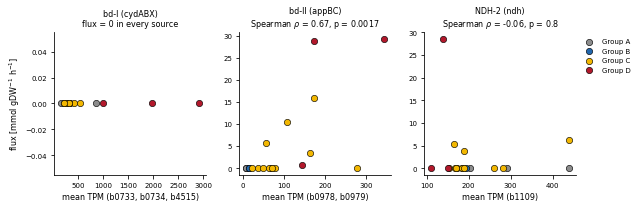

In [ ]:
# ---------------------------------------------------------------------------
# Low-coupling respiration: gene expression (TPM) vs iModulon-constrained flux
#
#   bd-I   cydABX  b0733 b0734 b4515   CYTBDpp  via CYT-D-UBIOX-CPLX
#   bd-II  appBC   b0978 b0979         CYTBD2pp + CYTBDpp via APP-UBIOX-CPLX
#   NDH-2  ndh     b1109               NADH10   via NADH-DHII-MONOMER
#
# x = mean TPM over the enzyme's subunits (replicates averaged per source)
# y = net flux carried by that enzyme [mmol/gDW/h]; points coloured by group
# ---------------------------------------------------------------------------
import re
from scipy.stats import spearmanr

# substrate groups, plot order, and source -> group look-up
groups = OrderedDict([('A', group_A_subs), ('B', group_B_subs),
                      ('C', group_C_subs), ('D', group_D_subs)])
order = [s for subs in groups.values() for s in subs]
src_group = {s: g for g, subs in groups.items() for s in subs}
group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# ---- expression: average replicate TPMs into one column per nitrogen source
tpm_metadata = pd.read_excel('sample_table_TPMcolumn_to_nitrogen_source.xlsx',
                             engine='openpyxl')
tpm = pd.read_csv('tpm_qc_nitrogen42_labeled.csv').set_index('gene')
col_to_source = dict(zip(tpm_metadata['tpm_column'],
                         tpm_metadata['nitrogen_source']))
sample_to_source = {c: col_to_source[c.split('__', 1)[-1]] for c in tpm.columns}
tpm_by_source = tpm.rename(columns=sample_to_source).T.groupby(level=0).mean().T

# ---- flux: FWD +, REV -, summed over every ME reaction matching the pattern
F = pd.read_csv('fluxes/imod_constrained_fluxes.csv', index_col=0)
sign = pd.Series([-1.0 if '_REV_' in i else 1.0 for i in F.index], index=F.index)
Fs = F.mul(sign, axis=0)
flux = lambda pat: Fs.loc[Fs.index.str.contains(pat)].sum()[order]

# panel -> (genes, flux pattern)
panels = OrderedDict([
    ('bd-I (cydABX)', (['b0733', 'b0734', 'b4515'],
                       r'^CYTBDpp_(?:FWD|REV)_CYT-D-UBIOX-CPLX')),
    ('bd-II (appBC)', (['b0978', 'b0979'],
                       r'^CYTBD2?pp_(?:FWD|REV)_APP-UBIOX-CPLX')),
    ('NDH-2 (ndh)',   (['b1109'],
                       r'^NADH10_(?:FWD|REV)_NADH-DHII-MONOMER')),
])

# one panel per enzyme
fig, axes = plt.subplots(1, len(panels), figsize=(3.0 * len(panels), 3.0))
for ax, (name, (genes, pat)) in zip(axes, panels.items()):
    # x = mean expression of the enzyme's genes, y = flux through the enzyme
    xg = tpm_by_source.loc[genes, order].mean()
    yf = flux(pat)
    # scatter, one colour per substrate group
    for g in groups:
        idx = [s for s in order if src_group[s] == g]
        ax.scatter(xg[idx], yf[idx], s=40, facecolor=group_colors[g],
                   edgecolor='black', linewidth=0.6, zorder=3, label=f'Group {g}')
    # Spearman correlation (only if the flux actually varies between sources)
    if yf.nunique() > 1:
        rho, p = spearmanr(xg, yf)
        stat = rf'Spearman $\rho$ = {rho:.2f}, p = {p:.2g}'
    else:
        stat = 'flux = %g in every source' % yf.iloc[0]
    ax.set_title(name + '\n' + stat, fontsize=8)
    ax.set_xlabel('mean TPM (' + ', '.join(genes) + ')', fontsize=8)
    ax.tick_params(labelsize=7)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel(r'flux [mmol gDW$^{-1}$ h$^{-1}$]', fontsize=8)
axes[-1].legend(frameon=False, fontsize=7, loc='upper left', bbox_to_anchor=(1.0, 1.0))

fig.tight_layout()
# save as PNG and PDF
fig.savefig('figs/respiration_tpm_vs_flux.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/respiration_tpm_vs_flux.pdf', bbox_inches='tight', transparent=True)
plt.show()


## 19. Figure: bd-II respiration and succinate uptake, per nitrogen source

Two wide panels, laid out like the proteome bar chart. Each nitrogen source has two "needles" (lollipops):
- **coloured** = constrained model
- **white** = optimal model

Height = flux ÷ growth rate. Panel 1: bd-II oxidase. Panel 2: succinate uptake.

Saved as `figs/respiration_flux_per_mu_needle_horizontal.*`.

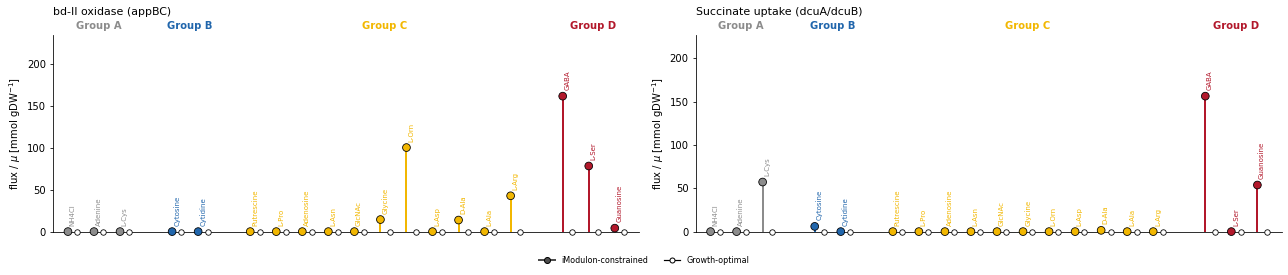

In [ ]:
# ---------------------------------------------------------------------------
# bd-II respiration and succinate uptake per nitrogen source, per unit growth
# (horizontal layout: substrates run along the x axis, needles point up;
#  1x2 panels, each as wide as the proteome allocation plot, same x layout)
#
#   bd-II  appBC  CYTBD2pp + CYTBDpp via APP-UBIOX-CPLX
#   dcuA/dcuB     succinate uptake, SUCCt2_3pp (succinate + 3 H+ symport), both isozymes
#
# two needles per nitrogen source:
#   left  (group colour) = iModulon-constrained
#   right (open, black)  = growth-optimal (uptake-constrained only)
# flux / mu [mmol/gDW], each solution divided by its OWN growth rate
# (biomass_dilution), so sources growing at different rates are comparable
# one unit per substrate, one blank unit between groups;
# each substrate is named just above its needle pair
# ---------------------------------------------------------------------------
from matplotlib.lines import Line2D

# substrate groups and their colours
groups = OrderedDict([('A', group_A_subs), ('B', group_B_subs),
                      ('C', group_C_subs), ('D', group_D_subs)])
group_colors = {'A': '#8C8C8C', 'B': '#2166AC', 'C': '#F2B701', 'D': '#B2182B'}

# panel title -> pattern that matches the reaction IDs to add up
panels = OrderedDict([
    ('bd-II oxidase (appBC)',        r'^CYTBD2?pp_(?:FWD|REV)_APP-UBIOX-CPLX'),
    ('Succinate uptake (dcuA/dcuB)', r'^SUCCt2_3pp_(?:FWD|REV)_'),
])

# ---- x layout: one unit per substrate, one blank unit between blocks ------
order, xpos, colors, pos = [], [], [], 0.0
block_centers = OrderedDict()
for g, subs in groups.items():
    start = pos
    for s in subs:
        order.append(s)
        xpos.append(pos)
        colors.append(group_colors[g])
        pos += 1
    block_centers[g] = (start + pos - 1) / 2.0
    pos += 1
xpos = np.array(xpos)

# ---- flux / mu: FWD +, REV -, summed over every ME reaction matching pat ---
def per_mu(path):
    F = pd.read_csv(path, index_col=0)
    sign = pd.Series([-1.0 if '_REV_' in i else 1.0 for i in F.index], index=F.index)
    Fs = F.mul(sign, axis=0)
    mu = F.loc['biomass_dilution', order]                            # [1/h]
    return lambda pat: (Fs.loc[Fs.index.str.contains(pat)].sum()[order] / mu).values

# flux-per-mu functions for each solution
imod_per_mu = per_mu('fluxes/imod_constrained_fluxes.csv')     # iModulon-constrained
opt_per_mu  = per_mu('fluxes/uptake_constrained_fluxes.csv')   # growth-optimal

d = 0.18                                     # half-spacing of each needle pair
PANEL_W = 9                                  # proteome allocation figure width [in]
fig, axes = plt.subplots(1, len(panels), figsize=(PANEL_W * len(panels), 3.5))
for ax, (name, pat) in zip(axes, panels.items()):
    # values for this panel: constrained and optimal
    v, v_opt = imod_per_mu(pat), opt_per_mu(pat)

    # coloured needles: constrained
    ax.vlines(xpos - d, 0, v, color=colors, lw=2.0, zorder=2)
    ax.scatter(xpos - d, v, s=60, facecolor=colors, edgecolor='black',
               linewidth=0.8, zorder=3, clip_on=False)

    # white needles: optimal
    ax.vlines(xpos + d, 0, v_opt, color='black', lw=1.2, zorder=2)
    ax.scatter(xpos + d, v_opt, s=30, facecolor='white', edgecolor='black',
               linewidth=0.8, zorder=3, clip_on=False)

    # substrate name just above each pair's taller needle
    for xi, vi, s, c in zip(xpos, np.maximum(v, v_opt), order, colors):
        ax.annotate(s, (xi, vi), xytext=(0, 6), textcoords='offset points',
                    ha='center', va='bottom', rotation=90, fontsize=7, color=c,
                    annotation_clip=False)

    # axis limits, labels and styling
    ax.set_xlim(-0.75, pos - 1.25)           # same as the proteome bars
    ax.set_ylim(0, max(v.max(), v_opt.max()) * 1.45)   # headroom for the labels
    ax.set_xticks([])
    ax.set_ylabel(r'flux / $\mu$ [mmol gDW$^{-1}$]')
    ax.set_title(name, loc='left', fontsize=11, pad=20)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

    # group labels above each panel (x in data coords, y in axes coords)
    for g, xc in block_centers.items():
        ax.text(xc, 1.02, f'Group {g}', ha='center', va='bottom', fontsize=10,
                color=group_colors[g], fontweight='bold',
                transform=ax.get_xaxis_transform())

# one shared legend below both panels
fig.legend(handles=[
        Line2D([], [], color='0.3', lw=2.0, marker='o', markersize=6,
               markerfacecolor='0.3', markeredgecolor='black', label='iModulon-constrained'),
        Line2D([], [], color='black', lw=1.2, marker='o', markersize=5,
               markerfacecolor='white', markeredgecolor='black', label='Growth-optimal')],
    loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False, fontsize=8)

fig.tight_layout()
# save as PNG, PDF and SVG
fig.savefig('figs/respiration_flux_per_mu_needle_horizontal.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/respiration_flux_per_mu_needle_horizontal.pdf', bbox_inches='tight', transparent=True)
fig.savefig('figs/respiration_flux_per_mu_needle_horizontal.svg', bbox_inches='tight', transparent=True)
plt.show()


## 20. Figure: heatmaps of which iModulon reactions changed

One heatmap per iModulon group (NtrC, GadX, ArcA/Fnr).
- **Columns** = reactions done by enzymes from that iModulon (transport reactions left out)
- **Rows** = nitrogen sources, split into groups A–D
- **Colour** = constrained minus optimal flux, per μ. **Red** = higher in the real cell, **blue** = lower, white = no change.

Reactions that never change by at least `MIN_DEV` are dropped to keep it readable.

Saved as `figs/imodulon_reaction_flux_deviation_heatmap.*`.

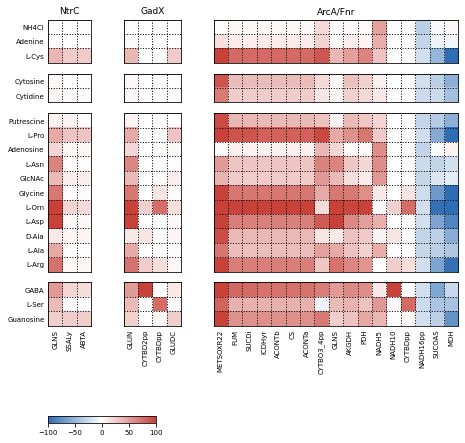

In [ ]:

# ---------------------------------------------------------------------------
# Heatmaps: v/mu - v_optimal/mu_optimal for the enzymatic reactions catalysed
# by the sector iModulons (transport excluded), one heatmap per iModulon group,
# substrates on the y axis grouped by type (A / B / C / D)
# ---------------------------------------------------------------------------
MIN_DEV = 10.0    # drop reactions with max |deviation| below this (blank rows) [mmol/gDW]
VMAX    = 100     # colour limit [mmol/gDW]
CELL    = 0.2     # cell size [inch]
GAP     = 0.15    # space between substrate groups / between heatmaps [inch]
LABELS  = 1.0     # space for reaction names below [inch]

# load the ME-model only if it is not loaded yet
if 'base_me' not in globals():
    with open(join(dirname(abspath(ecolime.__file__)), "me_models", "iJL1678b.pickle"), "rb") as f:
        base_me = pickle.load(f)

# the genes that make the enzyme for reaction r
def genes_of(r):
    return {m.replace('protein_', '').split('_')[0]
            for m in r.complex_data.stoichiometry if m.startswith('protein_')}

def is_transport(r):   # a metabolite other than H+ crosses, or only H+ is involved (Htex)
    comps = {}
    for m in r.stoichiometric_data.stoichiometry:
        name, _, c = m.rpartition('_')
        if c in ('c', 'p', 'e'):
            comps.setdefault(name, set()).add(c)
    return set(comps) == {'h'} or any(len(c) > 1 for n, c in comps.items() if n != 'h')

# all enzyme-catalysed metabolic reactions, transport left out
enzymatic = [r for r in base_me.reactions
             if isinstance(r, cobrame.MetabolicReaction) and r.complex_data is not None
             and not is_transport(r)]

D = new_spec - old_spec      # change from optimal, per unit growth [mmol/gDW]

# for each iModulon group: find its reactions, drop small changes, sort by average change
heatmaps = []
for gname, imods in imod_groups.items():
    genes = set().union(*[pd.read_pickle(f'imod_genes/{im}.pkl') for im in imods])
    rx = {_DIR.split(r.id)[0] for r in enzymatic if genes_of(r) & genes}
    H = D.loc[D.index.isin(rx), cols]        # cols = nitrogen sources present in both solutions (section 6)
    H = H[H.abs().max(axis=1) >= MIN_DEV]
    heatmaps.append((gname, H.loc[H.mean(axis=1).sort_values(ascending=False).index]))

# colours: blue = lower than optimal, white = same, red = higher
template_cmap = LinearSegmentedColormap.from_list('template', ['#2F6DB5', '#FFFFFF', '#C8423A'])

# ---- layout in inches: heatmaps side by side, substrate groups stacked ----
blocks = [[s for s in subs if s in cols] for subs in substrate_groups.values()]
height = sum(len(b) for b in blocks) * CELL + GAP * (len(blocks) - 1)
width  = sum(len(H) for _, H in heatmaps) * CELL + 3 * GAP * (len(heatmaps) - 1)
left, top, bottom = 0.9, 0.4, LABELS + 0.6           # room for substrate names / titles / reaction names + colourbar
fig = plt.figure(figsize=(left + width + 0.2, top + height + bottom))
FW, FH = fig.get_size_inches()

# draw one small heatmap per (iModulon group, substrate group) block
x = left
for i, (gname, H) in enumerate(heatmaps):
    y = top
    for j, subs in enumerate(blocks):
        ax = fig.add_axes([x / FW, 1 - (y + len(subs) * CELL) / FH,
                           len(H) * CELL / FW, len(subs) * CELL / FH])
        im = ax.imshow(H[subs].T.values, cmap=template_cmap, vmin=-VMAX, vmax=VMAX, aspect='auto')
        ax.set_xticks(np.arange(len(H) + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(len(subs) + 1) - 0.5, minor=True)
        ax.grid(which='minor', color='black', ls=':', lw=1)
        ax.tick_params(which='both', length=0)
        ax.set_yticks(range(len(subs)))
        ax.set_yticklabels(subs if i == 0 else [], fontsize=7)
        ax.set_xticks(range(len(H)))
        ax.set_xticklabels(H.index if j == len(blocks) - 1 else [], rotation=90, fontsize=7)
        if j == 0:
            ax.set_title(gname.split('(')[-1].rstrip(')'), fontsize=9)
        y += len(subs) * CELL + GAP
    x += len(H) * CELL + 3 * GAP

# colour bar under the heatmaps
cax = fig.add_axes([left / FW, 0.25 / FH, 1.5 / FW, 0.1 / FH])
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.ax.tick_params(labelsize=7)

# save as PNG and PDF
fig.savefig('figs/imodulon_reaction_flux_deviation_heatmap.png', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('figs/imodulon_reaction_flux_deviation_heatmap.pdf', bbox_inches='tight', transparent=True)
plt.show()
